# Project
### Ivan Acedo Aguilar
#### CS-5363 - Computer Vision

In [25]:
!pip install tifffile imaris_ims_file_reader numpy matplotlib cellpose
!pip install -q mediapipe


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [26]:
!curl -L -o deeplabv3.tflite https://storage.googleapis.com/mediapipe-models/image_segmenter/deeplab_v3/float32/1/deeplab_v3.tflite

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2715k  100 2715k    0     0  2341k      0  0:00:01  0:00:01 --:--:-- 2342k


In [27]:
from datetime import datetime
from skimage import exposure
from tifffile import tifffile
from imaris_ims_file_reader import ims
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from scipy.ndimage import correlate, gaussian_filter
from cellpose import models
import scipy.ndimage as nd
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import glob
import os

In [28]:
def save_cross(array, filename):
    slice_float = array.astype(np.float32)

    min_val = np.min(slice_float)
    max_val = np.max(slice_float)

    norm = (slice_float - min_val) / (max_val - min_val)
    
    corrected = best_gamma_corr(norm)

    slice_uint16 = (corrected * 65535).astype(np.uint16)

    tifffile.imwrite(filename, slice_uint16, resolution=(300, 300), resolutionunit="inch")

    print(f"Saved: {filename}")
    
    
def best_gamma_corr(img):
    img /= img.max()

    gamma_list = np.linspace(1.2, 3, 10)

    best_score = -np.inf
    best_img = img

    for g in gamma_list:
        corrected = exposure.adjust_gamma(img, g)
        score = corrected.std()

        if score > best_score:
            best_score = score
            best_img = corrected

    return best_img

def uniform_kernel(size):
    kernel = np.ones((size,size),dtype=np.float32)
    return kernel / kernel.sum()

In [29]:
count = 1
res = 4 #Not the highest resolution to help mediapipe work
n_slices = 25

In [30]:
return
start = datetime.now()
print(f"Started at: {start.strftime('%H:%M:%S')}\n")

path = "/Volumes/Extreme SSD/Ivan/NeuN Af647 3.6x 22_029.ims"
print(f"Loading IMS file: {path}\n")

# ims_data[Time, Channel, Z, Y, X]
ims_data = ims(path, ResolutionLevelLock=res)

print(f"\nData shape: {ims_data.shape}")

y_splits = [i * ims_data.shape[3] // n_slices for i in range(n_slices + 1)]

for i in range(n_slices):
    start_t = datetime.now()
    print(f"\n------->Slice {(i+1)} started at: {start_t.strftime('%H:%M:%S')}")

    slice_vol = ims_data[0, :, :, y_splits[i]:y_splits[i+1], :]
    
    print(F"Slice {(i+1)} Shape: {slice_vol.shape}")
    
    mid = slice_vol.shape[1] // 2
    
    slice_xz = slice_vol[:, mid:mid+10, :] # (Y-slice)
    slice_xz = slice_xz.max(axis=1)

    save_cross(slice_xz, f"NeuN_Af647_3.6x_{i}_xz_{count}.tiff")

    del slice_vol

    end_t = datetime.now()
    print(f"Slice {(i+1)} finished at: {end_t.strftime('%H:%M:%S')}")
    print(f"Total slice time: {end_t - start_t}<-------\n")

end = datetime.now()
print(f"\nFinished at: {end.strftime('%H:%M:%S')}")
print(f"Total time: {end - start}")

SyntaxError: 'return' outside function (3463659977.py, line 1)

In [31]:
# Load all generated TIFF files
tiff_paths = sorted(glob.glob("*.tiff"))

print(f"Found {len(tiff_paths)} files:")
for p in tiff_paths:
    print(f"  {p}")

Found 16 files:
  NeuN_Af647_3.6x_10_xz_1.tiff
  NeuN_Af647_3.6x_11_xz_1.tiff
  NeuN_Af647_3.6x_12_xz_1.tiff
  NeuN_Af647_3.6x_13_xz_1.tiff
  NeuN_Af647_3.6x_14_xz_1.tiff
  NeuN_Af647_3.6x_15_xz_1.tiff
  NeuN_Af647_3.6x_16_xz_1.tiff
  NeuN_Af647_3.6x_17_xz_1.tiff
  NeuN_Af647_3.6x_2_xz_1.tiff
  NeuN_Af647_3.6x_3_xz_1.tiff
  NeuN_Af647_3.6x_4_xz_1.tiff
  NeuN_Af647_3.6x_5_xz_1.tiff
  NeuN_Af647_3.6x_6_xz_1.tiff
  NeuN_Af647_3.6x_7_xz_1.tiff
  NeuN_Af647_3.6x_8_xz_1.tiff
  NeuN_Af647_3.6x_9_xz_1.tiff


In [ ]:
model = models.CellposeModel(gpu=False)

for i, path in enumerate(tiff_paths):
    array = tifffile.imread(path)  # shape: (C, H, W)

    print(array.shape)

    # Cellpose works directly on uint16, no need to convert
    masks, flows, styles = model.eval(
        array,
        diameter=None
    )

    # Save the mask
    base, ext = os.path.splitext(path)
    mask_path = f"{base}_cellpose_mask.tiff"
    tifffile.imwrite(mask_path, masks.astype(np.uint16))
    print(f"Saved: {mask_path} — {masks.max()} cells detected")

(279, 467)


KeyboardInterrupt: 

NeuN_Af647_3.6x_10_xz_1.tiff


I0000 00:00:1778701285.078212   31450 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
W0000 00:00:1778701285.080505   31452 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


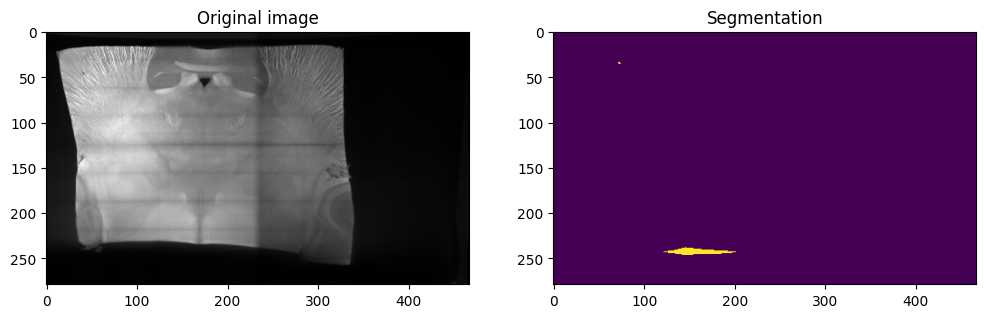

NeuN_Af647_3.6x_11_xz_1.tiff


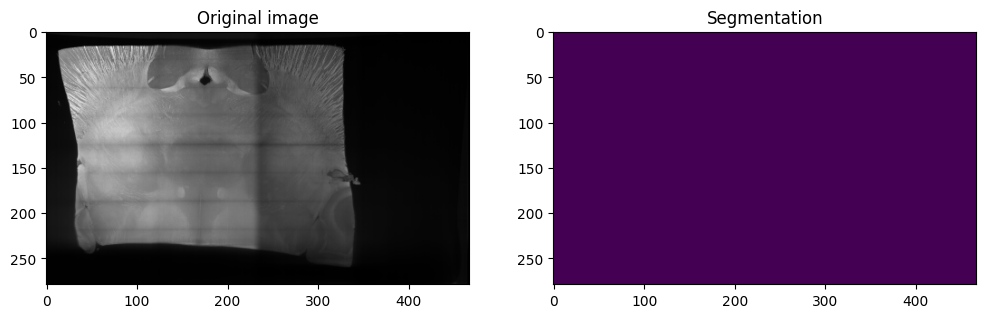

NeuN_Af647_3.6x_12_xz_1.tiff


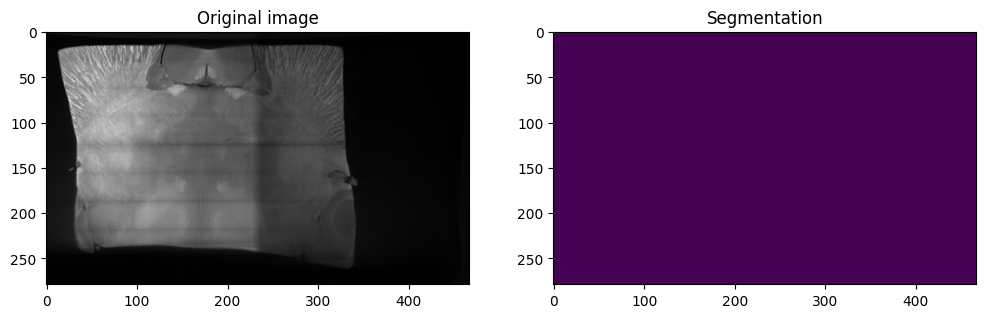

NeuN_Af647_3.6x_13_xz_1.tiff


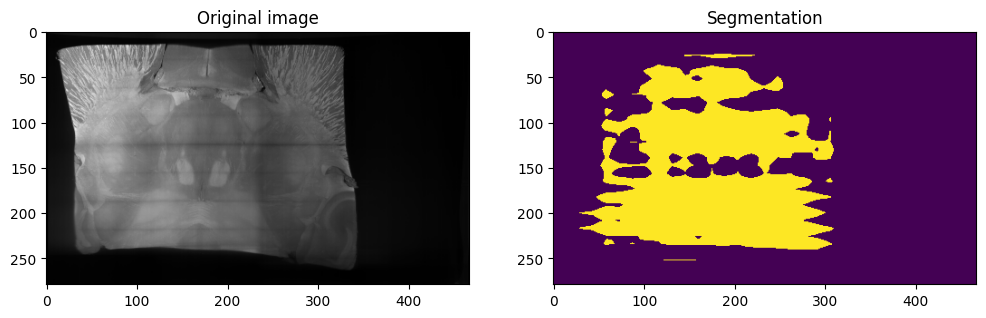

NeuN_Af647_3.6x_14_xz_1.tiff


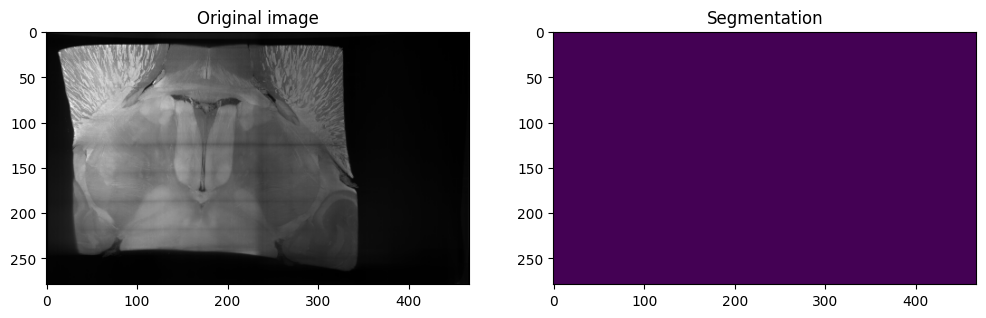

NeuN_Af647_3.6x_15_xz_1.tiff


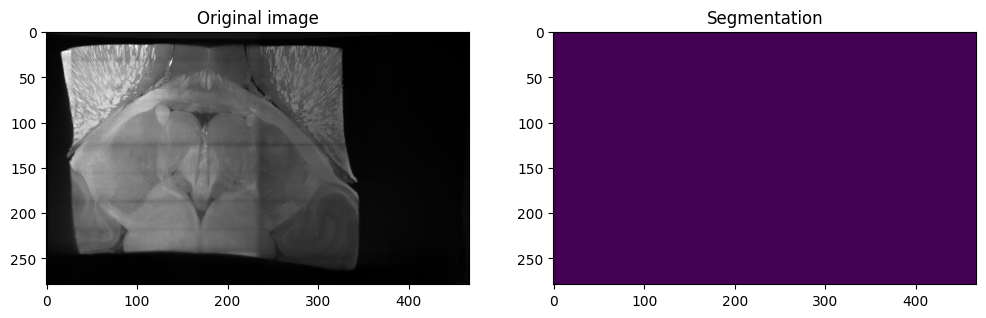

NeuN_Af647_3.6x_16_xz_1.tiff


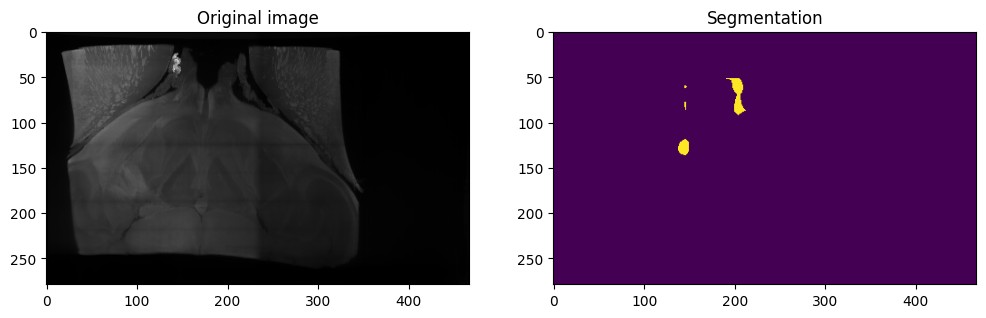

NeuN_Af647_3.6x_17_xz_1.tiff


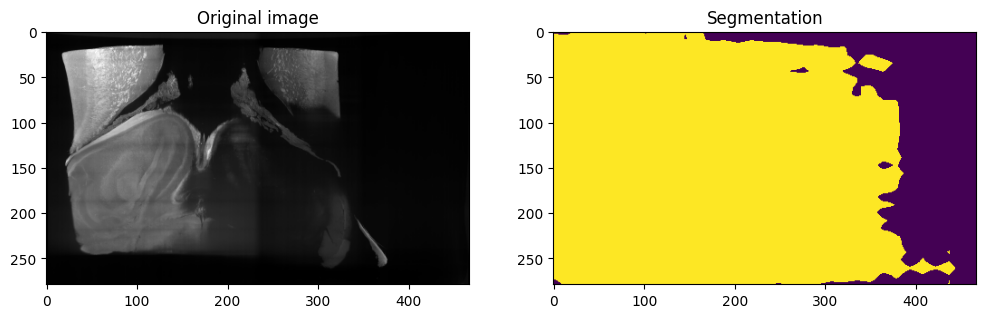

NeuN_Af647_3.6x_2_xz_1.tiff


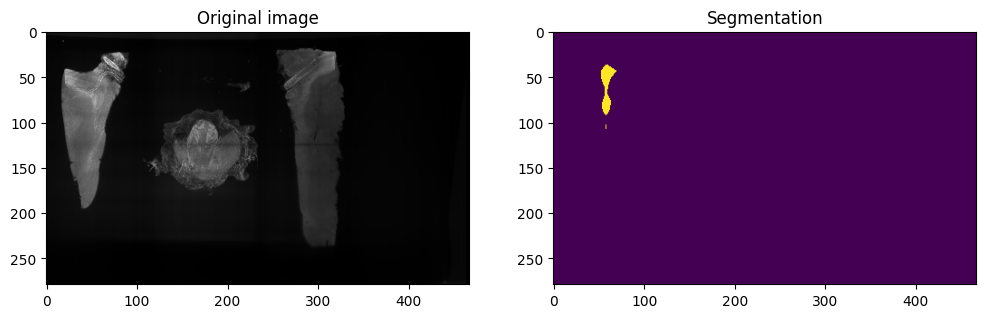

NeuN_Af647_3.6x_3_xz_1.tiff


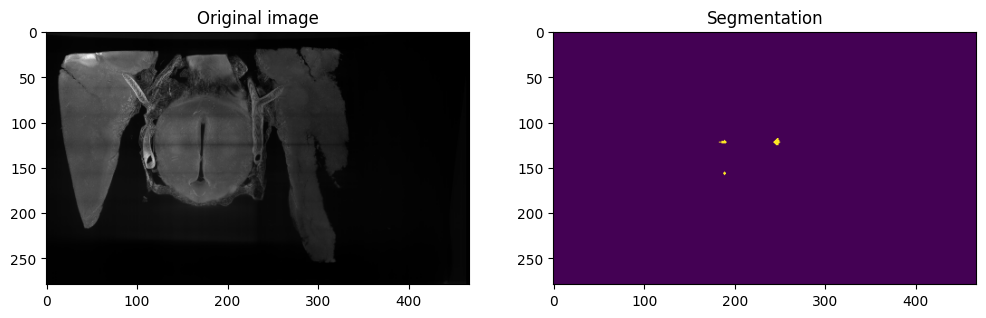

NeuN_Af647_3.6x_4_xz_1.tiff


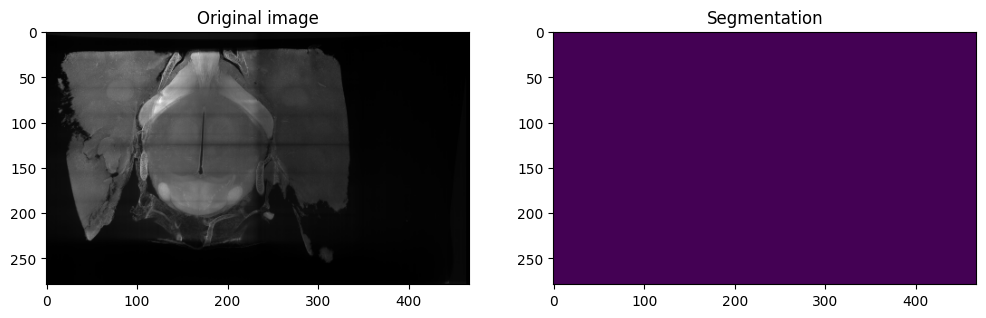

NeuN_Af647_3.6x_5_xz_1.tiff


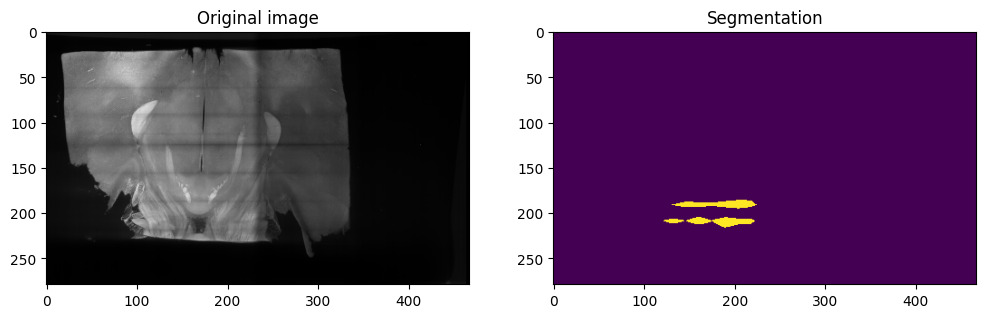

NeuN_Af647_3.6x_6_xz_1.tiff


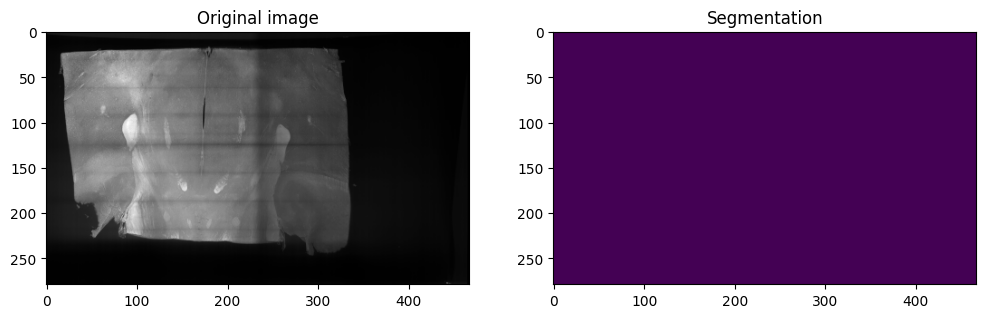

NeuN_Af647_3.6x_7_xz_1.tiff


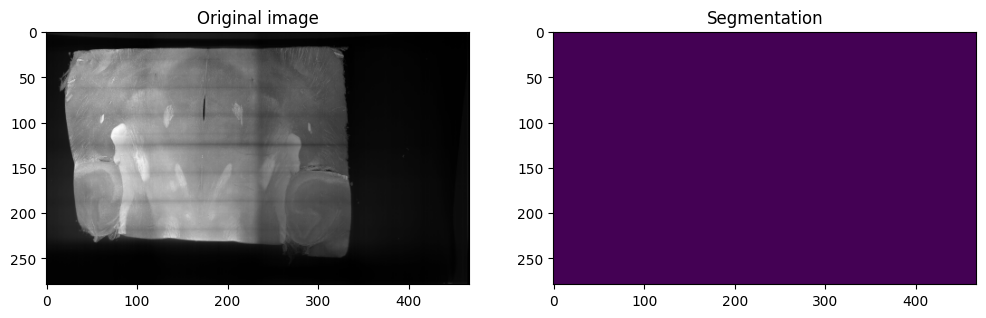

NeuN_Af647_3.6x_8_xz_1.tiff


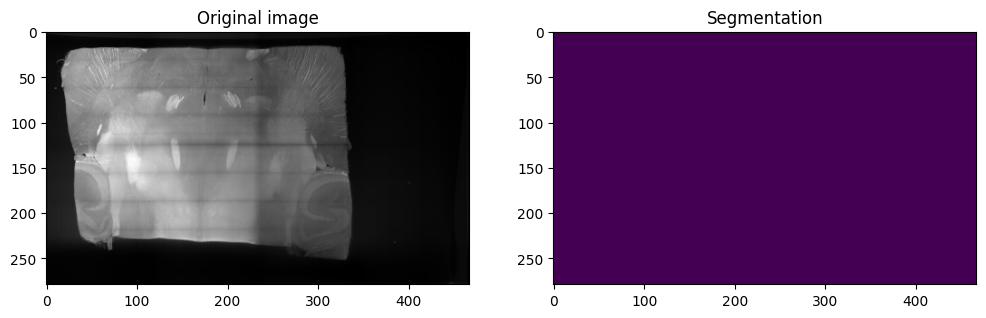

NeuN_Af647_3.6x_9_xz_1.tiff


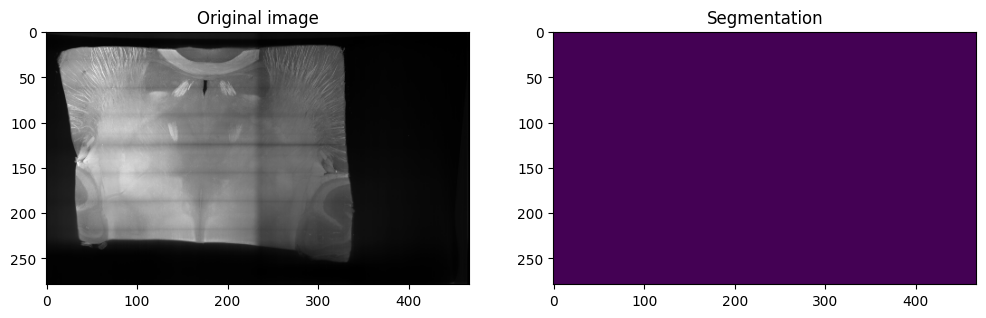

In [ ]:
base_options = python.BaseOptions(model_asset_path='deeplabv3.tflite')
options = vision.ImageSegmenterOptions(base_options=base_options, output_category_mask=True)

with vision.ImageSegmenter.create_from_options(options) as segmenter:

  # Loop through demo image(s)
  for i, path in enumerate(tiff_paths):
    fig, ax = plt.subplots(ncols=2, figsize=(12,16))
    # Create the MediaPipe image file that will be segmented
    array = tifffile.imread(path)
    img = nd.correlate(array,uniform_kernel(1))
    slice_uint8 = (img / 65535.0 * 255).astype(np.uint8)
    rgb = np.stack([slice_uint8] * 3, axis=-1)  # (H, W, 3)

    # Create MediaPipe image from numpy array directly (no file loading)
    image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    # Retrieve the masks for the segmented image
    segmentation_result = segmenter.segment(image)
    category_mask = segmentation_result.category_mask
    seg = np.int16(category_mask.numpy_view().squeeze(-1) > 0)
    print(f"{path:20}")

    ax[0].imshow(image.numpy_view())
    ax[0].set_title('Original image')
    ax[1].imshow(seg)
    ax[1].set_title('Segmentation')
    plt.show()
